# Imports and load data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import itertools

# %matplotlib widget
# plt.rc("text", usetex = False)
plt.rcParams["font.size"] = 16
# plt.rcParams["figure.facecolor"] = 'w'
# plt.style.use("classic")

fs = 20

def customCMAP(names = ["hot_r", "cool", "bone_r", "pink_r", "plasma_r"], ncolors: int = 256):

        for cmap in names:
            # if custom version of cmap already exists, skip it
            if cmap + 'T' in plt.colormaps():
                continue
            else:
            # create the colormap
                color_array = plt.get_cmap(cmap)(range(ncolors))
                color_array[:,-1] = np.power(np.linspace(0, 1.0, ncolors), 1/2) # adjusted so that the alpha increases quicker than linearly
                map_object = mcolors.LinearSegmentedColormap.from_list(name = cmap + 'T', colors = color_array)
                plt.colormaps.register(cmap = map_object)

customCMAP()

window_radius = 1e-2 # m

# Electron charge in C
e_charge = 1.602176634e-19

# ILC parameters
n_incident = 2.5e10 # number of electrons per bunch
n_bunches = 1312 # number of bunches per pulse
ILC_scale = n_bunches * n_incident # number of electrons in a bunch train

density = {
    "LXe": 2.953 * 1e6, # g/m^3
    "Be" : 1.848 * 1e6, # g/m^3
    "Al" : 2.699 * 1e6, # g/m^3
}

# n_electrons_per_pulse = n_incident / 20 # 20 beam pulses per bunch train WRONG ==> 1.25e9 e- per pulse
n_electrons_per_pulse = 66 * n_incident # 2.5e10 e- per bunch, 66 bunches in a pulse
pulse_time_sep = 3.3e-3 # 3.3 ms between pulses


In [429]:
materials = ["Be", "Al"]

def path(material: str, date: str = "jan2026", num: int = 4, ext: str = "out"):
    return f"/Users/max/SLAC Fall 2024/LXeSims/LXe_CFD_Target_Sims/datafilecell10v12{material}prof50us_{num}_{date}.{ext}"

data_cols = '"Time-Step" "flow-time" "delta-time" "dm-in-out" "flow-cellinds" "flow-cellinmidds" "flow-cellinmidus" "flow-cellinus" "flow-cellout" "iters-per-timestep" "p-inlet" "p-outlet" "power-inout" "rho-cell" "rhomin-cell" "tflow-cellout" "tflow-inlet" "tflow-outlet" "tmax-winin" "tmax-winout" "vflow-cell" "vflow-in" "vflow-outlet" "gasvolfrac-cell" "mdotlg-cell"'.replace('"', '').split(' ')

d_cols = "Absolute_time, vflow_R1, vflow_R2, density_R1, density_R2, Tave_R1, Tave_R2, Vol_R1, Vol_R2, number-of-cells_R1, number-of-cells_R2".replace(',','').split(' ')

In [425]:
data = pd.read_csv(path("Be", num=1), skiprows=3, delimiter=' ')
data.columns = '"Time-Step" "flow-time" "delta-time" "dm-in-out" "flow-cellinds" "flow-cellinmidds" "flow-cellinmidus" "flow-cellinus" "flow-cellout" "iters-per-timestep" "p-inlet" "p-outlet" "power-inout" "rho-cell" "rhomin-cell" "tflow-cellout" "tflow-inlet" "tflow-outlet" "tmax-winin" "tmax-winout" "vflow-cell" "vflow-in" "vflow-outlet" "gasvolfrac-cell" "mdotlg-cell"'.replace('"', '').split(' ')

# d contains data for cylindrical sub-volumes of the LXe
d = pd.read_csv(path("Be", num=1, ext="dat"), delimiter=' ')
d.columns = "Absolute_time, vflow_R1, vflow_R2, density_R1, density_R2, Tave_R1, Tave_R2, Vol_R1, Vol_R2, number-of-cells_R1, number-of-cells_R2".replace(',','').split(' ')



In [422]:
Be_data = []
Al_data = []

Be_offsets = []
Al_offsets = []

for i in range(1,5):
    Be_data.append(pd.read_csv(path("Be", num=i), skiprows=3, delimiter=' '))
    Be_data[i-1].columns = data_cols
    Be_offsets.append(len(Be_data[i-1]) - 1)

    if i > 1:
        Al_data.append(pd.read_csv(path("Al", date='dec2025', num=i), skiprows=3, delimiter=' '))
        Al_data[i-2].columns = data_cols
        Al_offsets.append(len(Be_data[i-2]) - 1)

Be = pd.concat(Be_data, ignore_index=True)
Al = pd.concat(Al_data, ignore_index=True)

Al_time_shifted = Al["Time-Step"] * Al["delta-time"] - Al["Time-Step"][0] * Al["delta-time"][0]
Be_time_shifted = Be["Time-Step"] * Be["delta-time"] - Be["Time-Step"][0] * Be["delta-time"][0]

Be_offsets = list(itertools.accumulate(Be_offsets))
Al_offsets = list(itertools.accumulate(Al_offsets))

In [440]:
Be_d = []
Al_d = []

Be_doff = []
Al_doff = []

for i in range(1,5):
    Be_d.append(pd.read_csv(path("Be", num=i, ext="dat"), skiprows=3, delimiter=' '))
    Be_d[i-1].columns = d_cols
    Be_doff.append(len(Be_d[i-1]) - 1)

    if i > 1:
        Al_d.append(pd.read_csv(path("Al", date='dec2025', num=i, ext="dat"), skiprows=3, delimiter=' '))
        Al_d[i-2].columns = d_cols
        Al_doff.append(len(Be_d[i-2]) - 1)

Be_df = pd.concat(Be_d, ignore_index=True)
Al_df = pd.concat(Al_d, ignore_index=True)

Be_doff = list(itertools.accumulate(Be_doff))
Al_doff = list(itertools.accumulate(Al_doff))

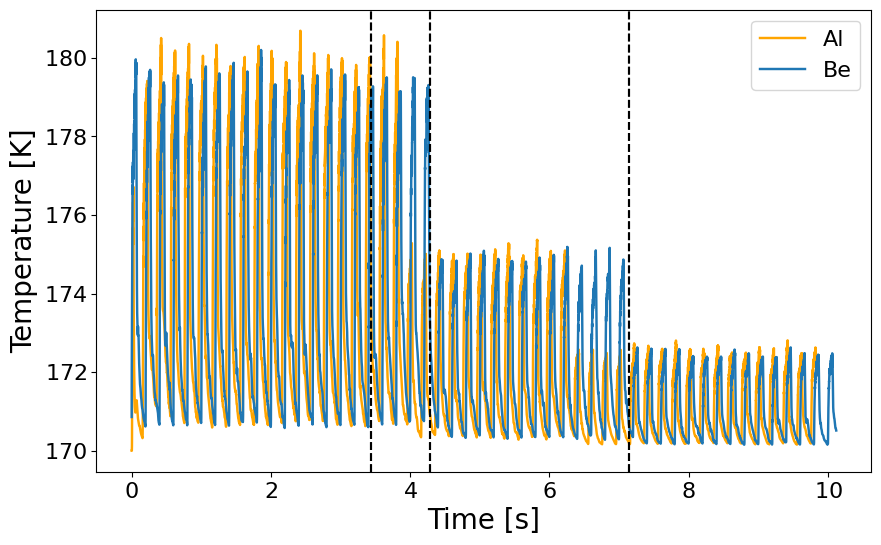

In [423]:
var = "tflow-cellout"

plt.close()
plt.figure(figsize=(10,6))

plt.plot(Al_time_shifted, Al[var], c='orange', label="Al", lw=1.75)
plt.plot(Be_time_shifted, Be[var], c='tab:blue', label="Be", lw=1.75)

for i in range(0, len(Al_offsets)):
    plt.axvline(Al_time_shifted[Al_offsets[i]], 0, 1, c='k', ls='--')
    plt.axvline(Be_time_shifted[Be_offsets[i]], 0, 1, c='k', ls='--')

plt.xlabel("Time [s]", fontsize=fs)
plt.ylabel("Temperature [K]", fontsize=fs)

plt.legend()

plt.savefig(f"/Users/max/SLAC Fall 2024/LXeSims/Figures/{var}.pdf", dpi=500, bbox_inches="tight")

plt.show()

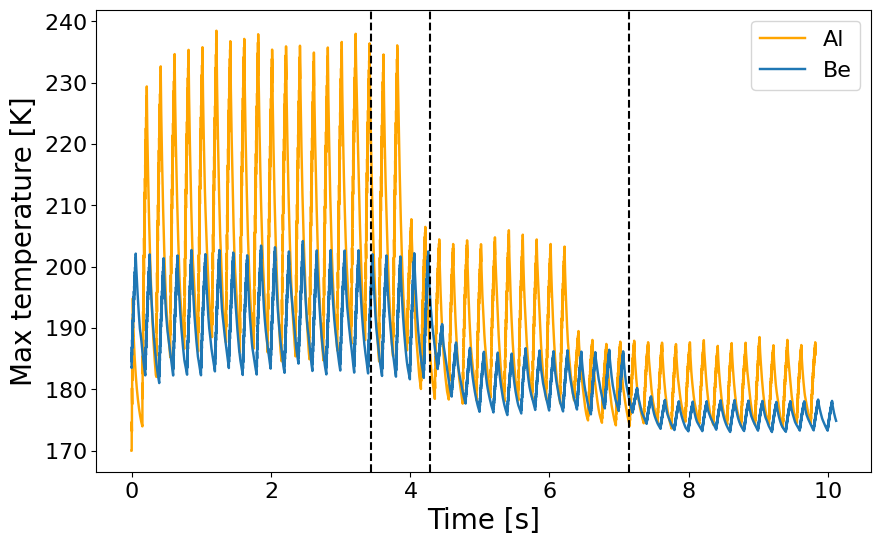

In [284]:
var = "tmax-winout"

plt.close()
plt.figure(figsize=(10,6))

plt.plot(Al_time_shifted, Al[var], c='orange', label="Al", lw=1.75)
plt.plot(Be_time_shifted, Be[var], c='tab:blue', label="Be", lw=1.75)

for i in range(0, len(Al_offsets)):
    plt.axvline(Al_time_shifted[Al_offsets[i]], 0, 1, c='k', ls='--')

plt.xlabel("Time [s]", fontsize=fs)
plt.ylabel("Max temperature [K]", fontsize=fs)

plt.legend()

plt.savefig(f"/Users/max/SLAC Fall 2024/LXeSims/Figures/{var}.pdf", dpi=500, bbox_inches="tight")

plt.show()

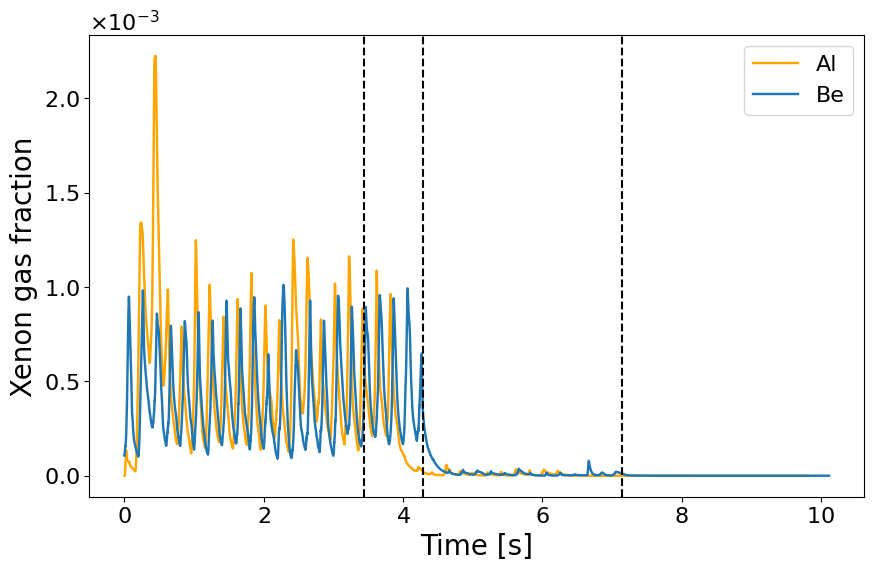

In [285]:
var = "gasvolfrac-cell"

plt.close()
plt.figure(figsize=(10,6))

plt.plot(Al_time_shifted, Al[var], c='orange', label="Al", lw=1.75)
plt.plot(Be_time_shifted, Be[var], c='tab:blue', label="Be", lw=1.75)

for i in range(0, len(Al_offsets)):
    plt.axvline(Al_time_shifted[Al_offsets[i]], 0, 1, c='k', ls='--')

plt.xlabel("Time [s]", fontsize=fs)
plt.ylabel("Xenon gas fraction", fontsize=fs)

plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
# plt.rcParams['axes.formatter.use_mathtext'] = True

plt.legend()

plt.savefig(f"/Users/max/SLAC Fall 2024/LXeSims/Figures/{var}.pdf", dpi=500, bbox_inches="tight")

plt.show()

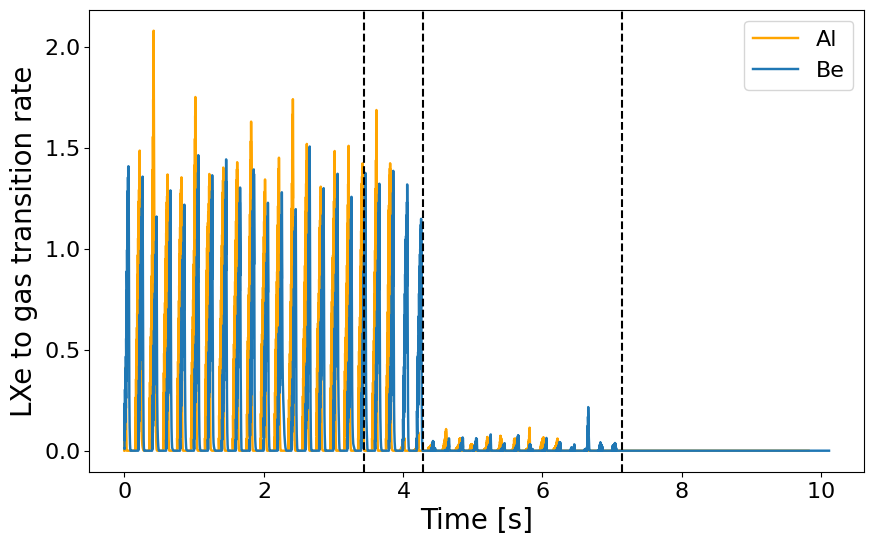

In [378]:
var = "mdotlg-cell"

plt.close()
plt.figure(figsize=(10,6))

plt.plot(Al_time_shifted, Al[var], c='orange', label="Al", lw=1.75)
plt.plot(Be_time_shifted, Be[var], c='tab:blue', label="Be", lw=1.75)

for i in range(0, len(Al_offsets)):
    plt.axvline(Al_time_shifted[Al_offsets[i]], 0, 1, c='k', ls='--')

plt.xlabel("Time [s]", fontsize=fs)
plt.ylabel("LXe to gas transition rate", fontsize=fs)

plt.legend()

plt.savefig(f"/Users/max/SLAC Fall 2024/LXeSims/Figures/{var}.pdf", dpi=500, bbox_inches="tight")

plt.show()

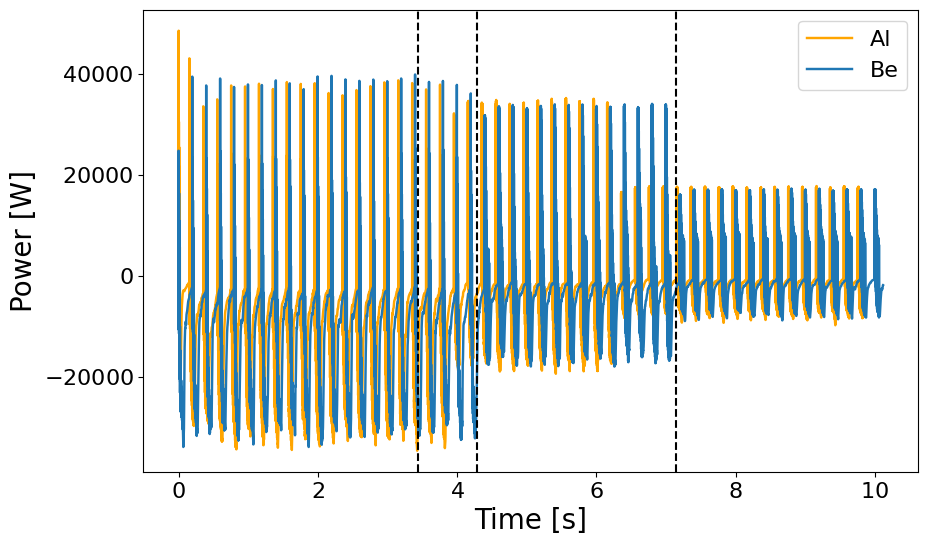

In [287]:
var = "power-inout"

plt.close()
plt.figure(figsize=(10,6))

plt.plot(Al_time_shifted, Al[var], c='orange', label="Al", lw=1.75)
plt.plot(Be_time_shifted, Be[var], c='tab:blue', label="Be", lw=1.75)

for i in range(0, len(Al_offsets)):
    plt.axvline(Al_time_shifted[Al_offsets[i]], 0, 1, c='k', ls='--')

plt.xlabel("Time [s]", fontsize=fs)
plt.ylabel("Power [W]", fontsize=fs)

plt.legend()

plt.savefig(f"/Users/max/SLAC Fall 2024/LXeSims/Figures/{var}.pdf", dpi=500, bbox_inches="tight")

plt.show()

# Paper plots

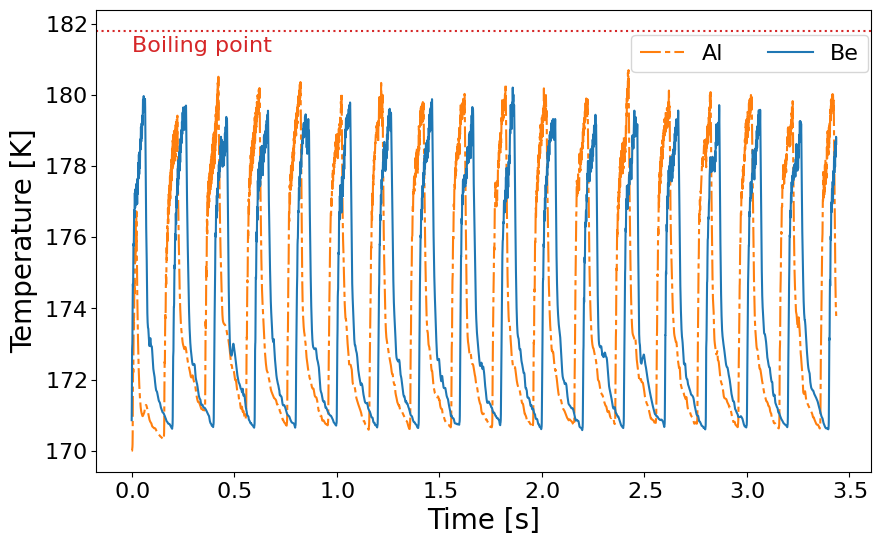

In [396]:
var = "tflow-cellout"

T_sat = 181.8

plt.close()
plt.figure(figsize=(10,6))

plt.plot(Al_time_shifted[:Al_offsets[0]], Al[var][:Al_offsets[0]], c='tab:orange', label="Al", lw=1.5, ls=(0, (10, 2, 2.5, 2)))
plt.plot(Be_time_shifted[:Be_offsets[0]], Be[var][:Be_offsets[0]], c='tab:blue', label="Be", lw=1.5)

plt.axhline(T_sat, 0, 1, ls=':', c='tab:red')
plt.text(0, T_sat-0.6, s="Boiling point", c='tab:red')

plt.xlabel("Time [s]", fontsize=fs)
plt.ylabel("Temperature [K]", fontsize=fs)
# plt.ylim(top=183)

plt.legend(loc="upper right"
            , ncols=2
            # , framealpha=0.5
            , bbox_to_anchor=(1.01, 0.97)
            # , bbox_to_anchor=(1, -0.015)
            )

plt.savefig(f"/Users/max/SLAC Fall 2024/LXeSims/Figures/{var}_trimmed.pdf", dpi=500, bbox_inches="tight")

plt.show()

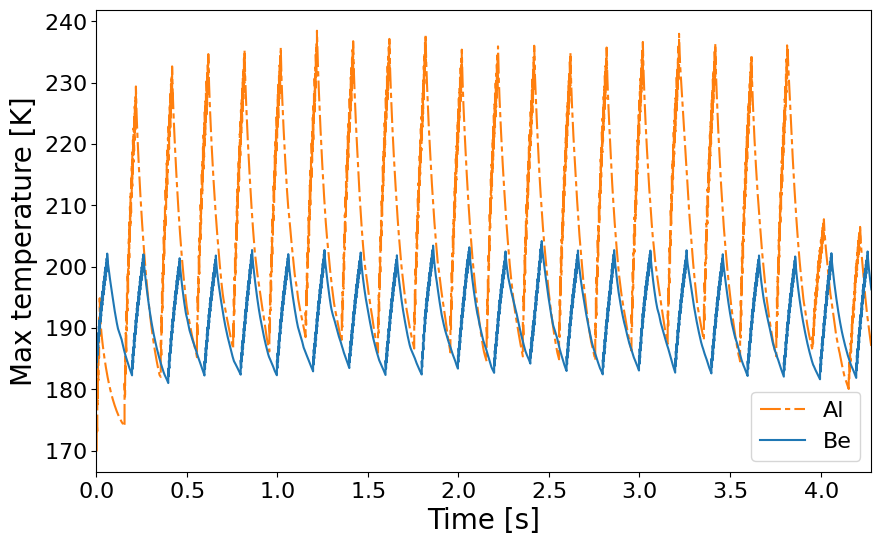

In [375]:
var = "tmax-winout"

plt.close()
plt.figure(figsize=(10,6))

plt.plot(Al_time_shifted, Al[var], c='tab:orange', label="Al", lw=1.5, ls=(0, (10, 2, 2.5, 2)))
plt.plot(Be_time_shifted, Be[var], c='tab:blue', label="Be", lw=1.5)

plt.xlabel("Time [s]", fontsize=fs)
plt.ylabel("Max temperature [K]", fontsize=fs)
plt.xlim(left=0.0, right=Al_time_shifted[Al_offsets[1]])

plt.legend()

plt.savefig(f"/Users/max/SLAC Fall 2024/LXeSims/Figures/{var}_trimmed.pdf", dpi=500, bbox_inches="tight")

plt.show()

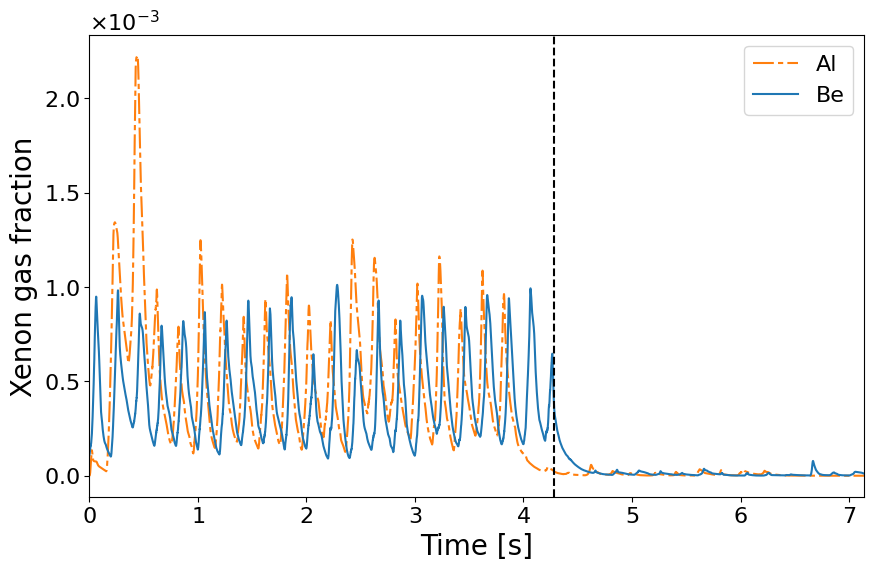

In [374]:
var = "gasvolfrac-cell"

plt.close()
plt.figure(figsize=(10,6))

plt.plot(Al_time_shifted, Al[var], c='tab:orange', label="Al", lw=1.5, ls=(0, (10, 2, 2.5, 2)))
plt.plot(Be_time_shifted, Be[var], c='tab:blue', label="Be", lw=1.5)
plt.axvline(Al_time_shifted[Al_offsets[1]], 0, 1, c='k', ls='--')

plt.xlabel("Time [s]", fontsize=fs)
plt.ylabel("Xenon gas fraction", fontsize=fs)


plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
# plt.rcParams['axes.formatter.use_mathtext'] = True
plt.xlim(left=0.0, right=Al_time_shifted[Al_offsets[2]])




plt.legend()

plt.savefig(f"/Users/max/SLAC Fall 2024/LXeSims/Figures/{var}_trimmed.pdf", dpi=500, bbox_inches="tight")

plt.show()

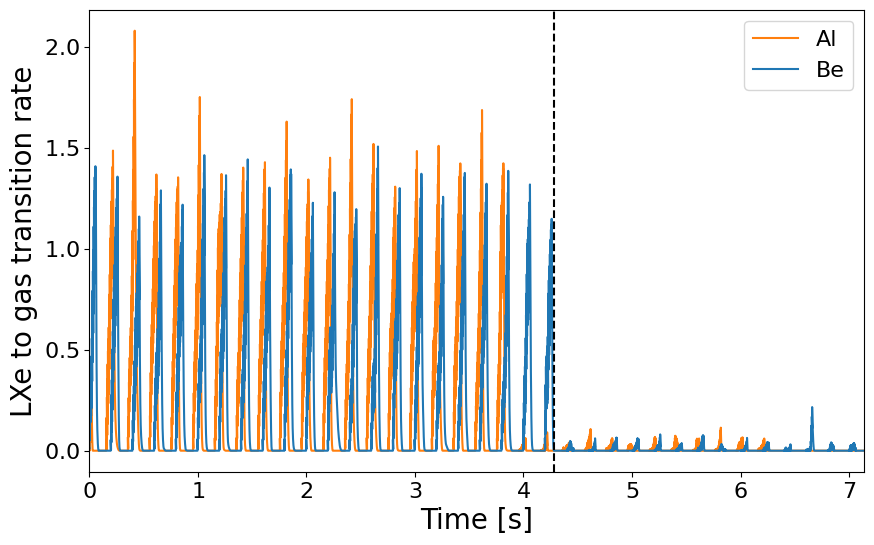

In [377]:
var = "mdotlg-cell"

plt.close()
plt.figure(figsize=(10,6))

plt.plot(Al_time_shifted, Al[var], c='tab:orange', label="Al", lw=1.5)
plt.plot(Be_time_shifted, Be[var], c='tab:blue', label="Be", lw=1.5)

plt.axvline(Al_time_shifted[Al_offsets[1]], 0, 1, c='k', ls='--')

plt.xlabel("Time [s]", fontsize=fs)
plt.ylabel("LXe to gas transition rate", fontsize=fs)
plt.xlim(left=0, right=Al_time_shifted[Al_offsets[2]])

plt.legend()

plt.savefig(f"/Users/max/SLAC Fall 2024/LXeSims/Figures/{var}_trimmed.pdf", dpi=500, bbox_inches="tight")

plt.show()

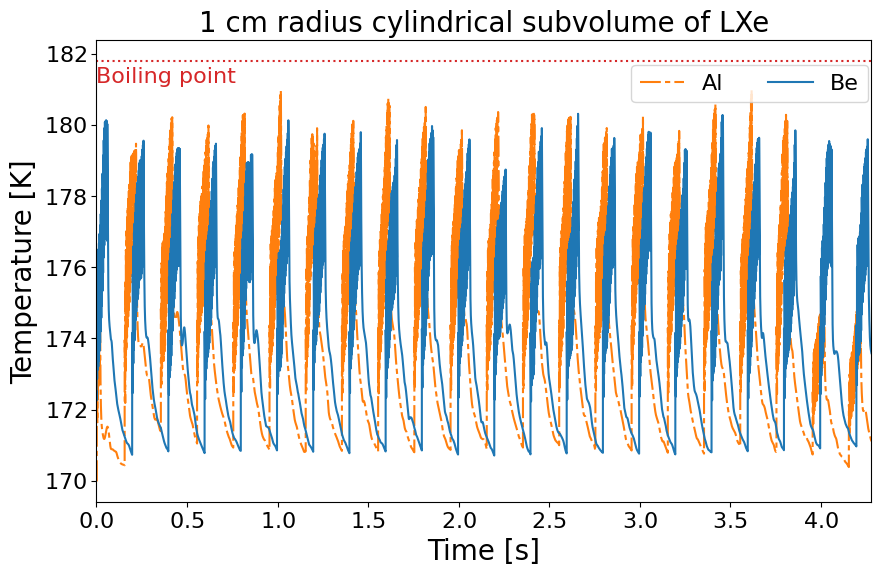

In [444]:
var = "Tave_R1"

T_sat = 181.8

Al_d_time_shifted = Al_df["Absolute_time"] - Al_df["Absolute_time"][0]

plt.close()
plt.figure(figsize=(10,6))

plt.plot(Al_d_time_shifted, Al_df[var], c='tab:orange', label="Al", lw=1.5, ls=(0, (10, 2, 2.5, 2)))
plt.plot(Be_df["Absolute_time"] - Be_df["Absolute_time"][0], Be_df[var], c='tab:blue', label="Be", lw=1.5)

plt.axhline(T_sat, 0, 1, ls=':', c='tab:red')
plt.text(0, T_sat-0.6, s="Boiling point", c='tab:red')

plt.xlim(left=0, right=Al_d_time_shifted[Al_doff[1]])

plt.xlabel("Time [s]", fontsize=fs)
plt.ylabel("Temperature [K]", fontsize=fs)
plt.title("1 cm radius cylindrical subvolume of LXe", fontsize=fs)

plt.legend(loc="upper right"
            , ncols=2
            # , framealpha=0.5
            , bbox_to_anchor=(1.01, 0.97)
            # , bbox_to_anchor=(1, -0.015)
            )

plt.savefig(f"/Users/max/SLAC Fall 2024/LXeSims/Figures/{var}_trimmed.pdf", dpi=500, bbox_inches="tight")

plt.show()